# 🏦 FinGuard AI — Final Model & Prediction

**Notebook:** 07 — Final Model & Prediction  
**Objective:** Load the optimized fraud model and saved threshold from Notebook 06, generate final predictions on the untouched test set, calculate fraud probability and risk score, evaluate the final model, and save application-ready prediction artifacts.

#### Workflow
Feature-Engineered Test Data → Optimized Fraud Model → Fraud Probability → Saved Threshold → Fraud/Legitimate Decision → Risk Score → Final Evaluation → Prediction Artifacts

> **Important:** The untouched test set is never SMOTE-balanced and is used only for final evaluation.


#### 1. Environment Setup

In [1]:
import sys
import warnings
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("FinGuard AI — Final Model & Prediction")
print("=" * 70)
print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)


FinGuard AI — Final Model & Prediction
Python : 3.11.15
NumPy  : 2.4.6
Pandas : 3.0.5


#### 2. Project Paths

Paths are derived from the notebook location. Existing FinGuard AI artifacts from the previous stages are used directly.


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Notebooks" else NOTEBOOK_DIR

DATASET_DIR = PROJECT_ROOT / "Dataset"
PROCESSED_DIR = DATASET_DIR / "Processed"
MODEL_DIR = PROJECT_ROOT / "Models"
REPORT_DIR = PROJECT_ROOT / "Reports"
MODEL_EVAL_DIR = REPORT_DIR / "Model_Evaluation"
PREDICTION_DIR = REPORT_DIR / "Predictions"

MODEL_EVAL_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

TEST_PATH = PROCESSED_DIR / "feature_engineered_test.csv"
OPTIMIZED_MODEL_PATH = MODEL_DIR / "optimized_fraud_model.joblib"
BEST_MODEL_PATH = MODEL_DIR / "best_fraud_model.joblib"
THRESHOLD_PATH = MODEL_DIR / "fraud_threshold_metadata.joblib"
FEATURE_METADATA_PATH = MODEL_DIR / "feature_engineering_metadata.joblib"
FINAL_METADATA_PATH = MODEL_DIR / "final_model_metadata.joblib"

print("Project Root :", PROJECT_ROOT)
print("Test Data    :", TEST_PATH)
print("Model        :", OPTIMIZED_MODEL_PATH)
print("Threshold    :", THRESHOLD_PATH)
print("Evaluation   :", MODEL_EVAL_DIR)
print("Predictions  :", PREDICTION_DIR)


Project Root : C:\Users\viqua\Desktop\FinGuard AI
Test Data    : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
Model        : C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
Threshold    : C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib
Evaluation   : C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation
Predictions  : C:\Users\viqua\Desktop\FinGuard AI\Reports\Predictions


#### 3. Input Artifact Validation

In [3]:
required = {
    "Feature-engineered test data": TEST_PATH,
    "Optimized fraud model": OPTIMIZED_MODEL_PATH,
    "Fraud threshold metadata": THRESHOLD_PATH,
    "Feature-engineering metadata": FEATURE_METADATA_PATH
}

for name, path in required.items():
    print(("✓ EXISTS" if path.exists() else "✗ MISSING").ljust(12), name, ":", path)

missing = [name for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts: " + ", ".join(missing))

print("\n✓ Input artifact validation passed")


✓ EXISTS     Feature-engineered test data : C:\Users\viqua\Desktop\FinGuard AI\Dataset\Processed\feature_engineered_test.csv
✓ EXISTS     Optimized fraud model : C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
✓ EXISTS     Fraud threshold metadata : C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib
✓ EXISTS     Feature-engineering metadata : C:\Users\viqua\Desktop\FinGuard AI\Models\feature_engineering_metadata.joblib

✓ Input artifact validation passed


#### 4. Load Feature-Engineered Test Data

In [4]:
test_df = pd.read_csv(TEST_PATH)
TARGET = "Class"

if TARGET not in test_df.columns:
    raise KeyError(f"Target column '{TARGET}' was not found.")

feature_columns = [c for c in test_df.columns if c != TARGET]
X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

print("✓ Test dataset loaded")
print(f"Test samples  : {len(test_df):,}")
print(f"Features      : {len(feature_columns)}")
print(f"Legitimate    : {int((y_test == 0).sum()):,}")
print(f"Fraud         : {int((y_test == 1).sum()):,}")


✓ Test dataset loaded
Test samples  : 56,746
Features      : 53
Legitimate    : 56,651
Fraud         : 95


#### 5. Validate Feature Order

In [5]:
feature_metadata = joblib.load(FEATURE_METADATA_PATH)

if isinstance(feature_metadata, dict):
    metadata_features = (
        feature_metadata.get("feature_columns")
        or feature_metadata.get("features")
        or feature_metadata.get("feature_names")
    )
else:
    metadata_features = None

if metadata_features is not None:
    metadata_features = list(metadata_features)
    missing = [c for c in metadata_features if c not in X_test.columns]
    if missing:
        raise ValueError(f"Missing expected features: {missing[:10]}")
    if len(metadata_features) == X_test.shape[1]:
        X_test = X_test[metadata_features]
        feature_columns = metadata_features

print(f"✓ Final feature matrix: {X_test.shape}")


✓ Final feature matrix: (56746, 53)


#### 6. Load Optimized Fraud Model

In [6]:
model_path = OPTIMIZED_MODEL_PATH if OPTIMIZED_MODEL_PATH.exists() else BEST_MODEL_PATH
final_model = joblib.load(model_path)

print("✓ Model loaded")
print("Model class:", type(final_model).__name__)

if hasattr(final_model, "n_features_in_"):
    if int(final_model.n_features_in_) != X_test.shape[1]:
        raise ValueError(
            f"Feature mismatch: model expects {final_model.n_features_in_}, "
            f"test data has {X_test.shape[1]}."
        )

print("✓ Model feature validation passed")


✓ Model loaded
Model class: XGBClassifier
✓ Model feature validation passed


#### 7. Load Saved Fraud Threshold

The threshold selected during optimization is reused. A new threshold is **not** selected using the test set.


In [7]:
# ============================================================
# 7. Load Saved Fraud Threshold
# ============================================================

threshold_metadata = joblib.load(THRESHOLD_PATH)

print("Threshold metadata type:", type(threshold_metadata).__name__)

# Show the actual saved structure
if isinstance(threshold_metadata, dict):
    print("Available keys:")
    for key, value in threshold_metadata.items():
        print(f"  {key} : {value}")
else:
    print("Saved threshold object:")
    print(threshold_metadata)


# ------------------------------------------------------------
# Extract threshold from common possible key names
# ------------------------------------------------------------

threshold = None

if isinstance(threshold_metadata, dict):

    possible_keys = [
        "threshold",
        "best_threshold",
        "optimal_threshold",
        "selected_threshold",
        "fraud_threshold",
        "decision_threshold",
        "optimal_fraud_threshold",
        "selected_fraud_threshold"
    ]

    for key in possible_keys:
        if key in threshold_metadata:
            threshold = threshold_metadata[key]
            print(f"\n✓ Threshold found using key: '{key}'")
            break

else:
    # If the .joblib directly contains a number
    if isinstance(threshold_metadata, (int, float, np.integer, np.floating)):
        threshold = threshold_metadata


if threshold is None:
    raise ValueError(
        "Could not automatically determine the fraud threshold. "
        "Check the printed metadata keys above."
    )


threshold = float(threshold)

if not 0 < threshold < 1:
    raise ValueError(
        f"Invalid fraud threshold: {threshold}. "
        "Expected a value between 0 and 1."
    )

print(f"\n✓ Selected fraud threshold: {threshold:.6f}")

Threshold metadata type: dict
Available keys:
  project : FinGuard AI
  target : Class
  model : XGBoost
  fraud_threshold : 0.8200000000000002
  threshold_selection_metric : F1 with recall priority
  validation_samples : 90641
  test_samples : 56746
  test_set_used_for_threshold_selection : False

✓ Threshold found using key: 'fraud_threshold'

✓ Selected fraud threshold: 0.820000


#### 8. Generate Fraud Probability / Score

In [8]:
start = time.time()

if hasattr(final_model, "predict_proba"):
    proba = np.asarray(final_model.predict_proba(X_test))
    fraud_probability = proba[:, 1] if proba.ndim == 2 else proba.reshape(-1)

elif hasattr(final_model, "decision_function"):
    scores = np.asarray(final_model.decision_function(X_test), dtype=float)
    fraud_probability = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

else:
    raise AttributeError("Model has neither predict_proba nor decision_function.")

fraud_probability = np.clip(fraud_probability.astype(float), 0, 1)

print(f"✓ Scores generated in {time.time() - start:.2f} seconds")
print(f"Minimum : {fraud_probability.min():.6f}")
print(f"Maximum : {fraud_probability.max():.6f}")
print(f"Mean    : {fraud_probability.mean():.6f}")


✓ Scores generated in 0.37 seconds
Minimum : 0.000000
Maximum : 1.000000
Mean    : 0.002081


#### 9. Apply Final Fraud Threshold

In [9]:
final_predictions = (fraud_probability >= threshold).astype(int)

print("✓ Final classifications generated")
print(f"Predicted Legitimate : {int((final_predictions == 0).sum()):,}")
print(f"Predicted Fraud      : {int((final_predictions == 1).sum()):,}")


✓ Final classifications generated
Predicted Legitimate : 56,664
Predicted Fraud      : 82


#### 10. Generate Risk Score and Risk Level

Risk Score = fraud probability × 100.

- Low: < 30
- Medium: 30–69.99
- High: ≥ 70


In [10]:
risk_score = fraud_probability * 100.0

risk_level = np.select(
    [risk_score >= 70, risk_score >= 30],
    ["High", "Medium"],
    default="Low"
)

print("Risk distribution:")
display(
    pd.Series(risk_level)
    .value_counts()
    .rename_axis("Risk_Level")
    .to_frame("Count")
)


Risk distribution:


,Count
Risk_Level,
Low,56629
High,86
Medium,31


#### 11. Final Test-Set Evaluation

In [11]:
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, zero_division=0)
recall = recall_score(y_test, final_predictions, zero_division=0)
f1 = f1_score(y_test, final_predictions, zero_division=0)
roc_auc = roc_auc_score(y_test, fraud_probability)
pr_auc = average_precision_score(y_test, fraud_probability)

final_metrics = pd.DataFrame([{
    "Model": type(final_model).__name__,
    "Threshold": threshold,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1_Score": f1,
    "PR_AUC": pr_auc,
    "ROC_AUC": roc_auc,
    "Test_Samples": len(y_test)
}])

display(final_metrics.style.format({
    "Threshold": "{:.6f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1_Score": "{:.4f}",
    "PR_AUC": "{:.4f}",
    "ROC_AUC": "{:.4f}"
}))


,Model,Threshold,Accuracy,Precision,Recall,F1_Score,PR_AUC,ROC_AUC,Test_Samples
0,XGBClassifier,0.820000,0.9995,0.8902,0.7684,0.8249,0.8162,0.9706,56746


#### 12. Classification Report & Confusion Matrix

Final Classification Report — XGBClassifier
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56651
       Fraud     0.8902    0.7684    0.8249        95

    accuracy                         0.9995     56746
   macro avg     0.9449    0.8841    0.9123     56746
weighted avg     0.9994    0.9995    0.9994     56746



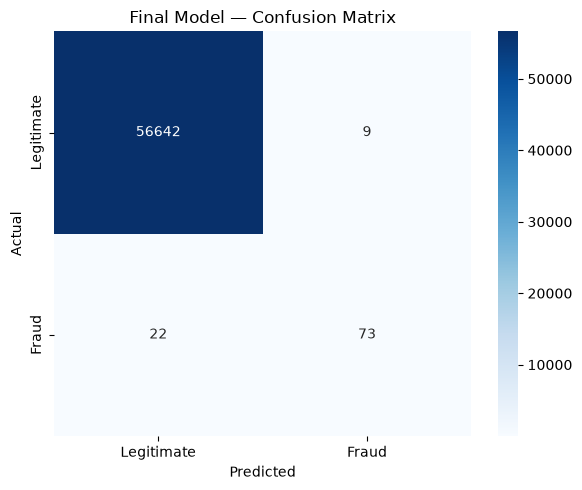

In [12]:
print(f"Final Classification Report — {type(final_model).__name__}")
print("=" * 70)
print(classification_report(
    y_test,
    final_predictions,
    target_names=["Legitimate", "Fraud"],
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.title("Final Model — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


#### 13. ROC Curve & Precision-Recall Curve

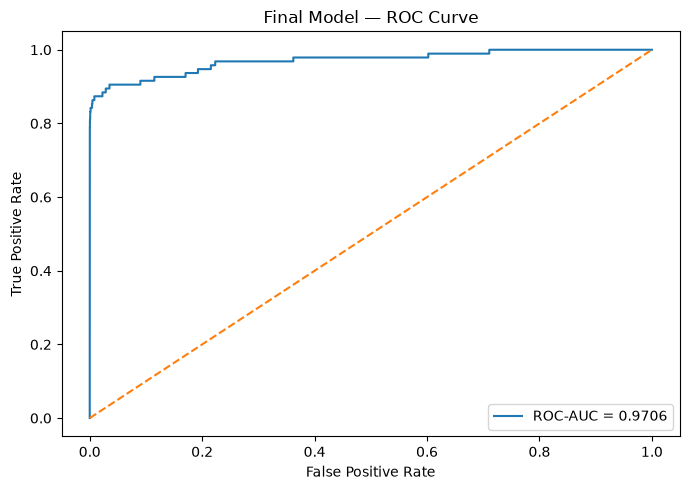

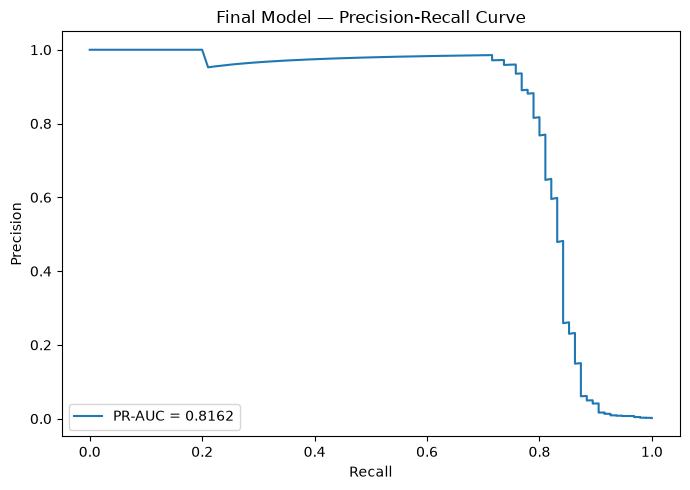

In [13]:
fpr, tpr, _ = roc_curve(y_test, fraud_probability)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

pr_precision, pr_recall, _ = precision_recall_curve(y_test, fraud_probability)

plt.figure(figsize=(7, 5))
plt.plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Model — Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()


#### 14. Create Final Prediction Dataset

In [14]:
prediction_df = test_df.copy()

prediction_df["Fraud_Probability"] = fraud_probability
prediction_df["Risk_Score"] = risk_score
prediction_df["Risk_Level"] = risk_level
prediction_df["Predicted_Class"] = final_predictions
prediction_df["Prediction"] = np.where(
    final_predictions == 1, "Fraud", "Legitimate"
)
prediction_df["Correct_Prediction"] = (
    prediction_df[TARGET].astype(int) == prediction_df["Predicted_Class"]
)

display(prediction_df.head(10))
print(f"Rows: {len(prediction_df):,}")


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Log1p,Amount_Sqrt,Amount_Squared,Amount_Is_Zero,Amount_Is_High,Time_Day_Index,Time_Hour,Time_Minute,Time_Hour_Sin,Time_Hour_Cos,Time_Day_Sin,Time_Day_Cos,V_Abs_Mean,V_Abs_Max,V_Abs_Std,V_L2_Norm,V_Positive_Count,V_Negative_Count,V_Extreme_Count,Risk_Deviation_Score,Risk_Max_Deviation,Risk_Extreme_Ratio,Risk_Severe_Ratio,Fraud_Probability,Risk_Score,Risk_Level,Predicted_Class,Prediction,Correct_Prediction
0,-0.707761,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,-0.273054,-1.252728,0.465079,0.400502,-0.292842,-0.101774,-0.399836,0.034336,-0.783550,0.141345,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,-0.312846,0,2.525729,3.391165,132.2500,0,0,0,17,1,-0.965926,-2.588190e-01,-0.967599,-0.252492,0.356453,1.252728,0.339762,2.583499,14,14,0,0.356453,1.252728,0.000000,0.0,4.720925e-06,0.000472,Low,0,Legitimate,True
1,1.273872,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,-0.506595,-1.394841,-0.092472,0.021634,0.730797,0.496343,-0.199594,-0.434390,0.348660,0.162524,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,-0.351745,0,1.078410,1.392839,3.7636,0,0,1,19,9,-0.965926,2.588190e-01,-0.953848,0.300290,0.475150,1.394841,0.353806,3.114692,14,14,0,0.475150,1.394841,0.000000,0.0,6.721923e-06,0.000672,Low,0,Legitimate,True
2,-1.348111,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,3.071219,0.768574,0.202065,1.349180,-0.950567,0.922046,0.366995,-1.215489,0.598610,1.425968,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,0.011771,0,4.524827,9.554057,8332.0384,0,0,0,8,34,0.866025,-5.000000e-01,0.780749,-0.624845,0.875665,3.071219,0.696690,5.880072,17,11,1,0.875665,3.071219,0.035714,0.0,1.282017e-05,0.001282,Low,0,Legitimate,True
3,-0.878056,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,0.871966,0.906599,0.386404,0.101522,0.275543,0.703471,-1.004960,-0.425904,1.774010,-1.399609,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,0.568071,0,5.433722,15.099669,51984.0000,0,0,0,14,46,-0.500000,-8.660254e-01,-0.664959,-0.746880,0.556587,1.774010,0.446058,3.747832,15,13,0,0.556587,1.774010,0.000000,0.0,3.779262e-06,0.000378,Low,0,Legitimate,True
4,0.727104,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,-0.527043,0.985105,1.036503,0.417644,-1.641894,-1.123470,0.316818,0.891983,0.610567,0.215798,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,-0.353901,0,0.879627,1.187434,1.9881,0,0,1,11,57,0.258819,-9.659258e-01,0.012435,-0.999923,0.559442,2.009701,0.546280,4.101307,17,11,0,0.559442,2.009701,0.000000,0.0,2.687612e-04,0.026876,Low,0,Legitimate,True
5,-0.633511,1.100851,0.157223,0.460898,1.144401,-0.262777,-0.207127,-0.069886,0.108077,-0.189285,0.202442,1.566345,0.646505,-0.781037,0.704609,0.550789,0.028562,-0.331793,-0.002078,-0.620951,-0.178526,0.165190,0.452340,-0.073263,0.222736,0.514541,-0.280895,0.023528,0.012033,-0.274232,0,3.090588,4.581484,440.5801,0,0,0,18,0,-1.000000,-1.836970e-16,-0.999999,0.001164,0.394953,1.566345,0.386686,2.899113,17,11,0,0.394953,1.566345,0.000000,0.0,1.532890e-04,0.015329,Low,0,Legitimate,True
6,-1.416149,-1.428601,-0.230183,0.913877,-0.555968,0.934244,-0.490981,1.585359,-0.453572,-0.813235,-0.349193,0.925020,0.697182,0.622506,0.088764,-0.399146,0.591161,-1.157471,-0.188943,0.125603,-0.046883,-0.426219,-1.140156,-0.199477,-0.323784,0.435417,0.051784,-0.215280,-0.349317,0.596147,0,5.463408,15.326448,55178.0100,0,0,0,7,40,0.965926,-2.588190e-01,0.904765,-0.425911,0.562119,1.585359,0.414248,3.671595,11,17,0,0.562119,1.585359,0.000000,0.0,4.144535e-06,0.000414,Low,0,Legitimate,True
7,-1.419623,-0.915128,0.500570,0.169310,-0

Rows: 56,746


#### 15. Save Final Prediction & Evaluation Artifacts

In [15]:
final_metrics_path = MODEL_EVAL_DIR / "final_prediction_metrics.csv"
classification_report_path = MODEL_EVAL_DIR / "final_classification_report.csv"
confusion_matrix_path = MODEL_EVAL_DIR / "final_confusion_matrix.csv"
prediction_path = PREDICTION_DIR / "final_test_predictions.csv"

final_metrics.to_csv(final_metrics_path, index=False)

pd.DataFrame(
    classification_report(
        y_test, final_predictions,
        target_names=["Legitimate", "Fraud"],
        output_dict=True,
        zero_division=0
    )
).T.to_csv(classification_report_path)

pd.DataFrame(
    cm,
    index=["Actual_Legitimate", "Actual_Fraud"],
    columns=["Predicted_Legitimate", "Predicted_Fraud"]
).to_csv(confusion_matrix_path)

prediction_df.to_csv(prediction_path, index=False)

print("✓ Final artifacts saved")
print(final_metrics_path)
print(classification_report_path)
print(confusion_matrix_path)
print(prediction_path)


✓ Final artifacts saved
C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\final_prediction_metrics.csv
C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\final_classification_report.csv
C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\final_confusion_matrix.csv
C:\Users\viqua\Desktop\FinGuard AI\Reports\Predictions\final_test_predictions.csv


#### 16. Save Final Model Metadata

In [16]:
final_metadata = {
    "project": "FinGuard AI",
    "stage": "07_Final_Model_Prediction",
    "model_file": str(model_path),
    "model_class": type(final_model).__name__,
    "target": TARGET,
    "feature_count": len(feature_columns),
    "feature_columns": list(feature_columns),
    "threshold": threshold,
    "test_samples": int(len(y_test)),
    "fraud_samples": int(y_test.sum()),
    "predicted_fraud_samples": int(final_predictions.sum()),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "pr_auc": float(pr_auc),
    "roc_auc": float(roc_auc),
    "test_set_smote": False,
    "prediction_artifact": str(prediction_path),
    "evaluation_artifact": str(final_metrics_path)
}

joblib.dump(final_metadata, FINAL_METADATA_PATH)

print("✓ Final metadata saved:")
print(FINAL_METADATA_PATH)


✓ Final metadata saved:
C:\Users\viqua\Desktop\FinGuard AI\Models\final_model_metadata.joblib


#### 17. Final Artifact Validation

In [17]:
expected_artifacts = [
    model_path,
    THRESHOLD_PATH,
    FINAL_METADATA_PATH,
    final_metrics_path,
    classification_report_path,
    confusion_matrix_path,
    prediction_path
]

print("Generated Final-Prediction Artifacts")
print("=" * 70)

for path in expected_artifacts:
    print(
        ("✓ EXISTS" if Path(path).exists() else "✗ MISSING").ljust(12),
        Path(path)
    )

if not all(Path(path).exists() for path in expected_artifacts):
    raise RuntimeError("One or more final prediction artifacts were not created.")

print("\n✓ Final artifact validation passed")


Generated Final-Prediction Artifacts
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\optimized_fraud_model.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\fraud_threshold_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Models\final_model_metadata.joblib
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\final_prediction_metrics.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\final_classification_report.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Model_Evaluation\final_confusion_matrix.csv
✓ EXISTS     C:\Users\viqua\Desktop\FinGuard AI\Reports\Predictions\final_test_predictions.csv

✓ Final artifact validation passed


#### 18. Final Model & Prediction Summary

In [18]:
print("=" * 75)
print("FIN GUARD AI — FINAL MODEL & PREDICTION COMPLETED")
print("=" * 75)
print(f"✓ Final Model          : {type(final_model).__name__}")
print(f"✓ Features Used        : {len(feature_columns)}")
print(f"✓ Test Samples         : {len(y_test):,}")
print(f"✓ Fraud Threshold      : {threshold:.6f}")
print(f"✓ Accuracy             : {accuracy:.4f}")
print(f"✓ Precision            : {precision:.4f}")
print(f"✓ Recall               : {recall:.4f}")
print(f"✓ F1-score             : {f1:.4f}")
print(f"✓ PR-AUC               : {pr_auc:.4f}")
print(f"✓ ROC-AUC              : {roc_auc:.4f}")
print(f"✓ Predicted Fraud      : {int(final_predictions.sum()):,}")
print(f"✓ Predicted Legitimate : {int((final_predictions == 0).sum()):,}")
print("✓ Test SMOTE           : Not Applied")
print("✓ Prediction Artifacts : Saved")
print("=" * 75)


FIN GUARD AI — FINAL MODEL & PREDICTION COMPLETED
✓ Final Model          : XGBClassifier
✓ Features Used        : 53
✓ Test Samples         : 56,746
✓ Fraud Threshold      : 0.820000
✓ Accuracy             : 0.9995
✓ Precision            : 0.8902
✓ Recall               : 0.7684
✓ F1-score             : 0.8249
✓ PR-AUC               : 0.8162
✓ ROC-AUC              : 0.9706
✓ Predicted Fraud      : 82
✓ Predicted Legitimate : 56,664
✓ Test SMOTE           : Not Applied
✓ Prediction Artifacts : Saved


#### 19. Next Stage

### Notebook 08 — Anomaly Detection

The next stage will add the unsupervised anomaly layer:

- Isolation Forest
- Anomaly score generation
- Anomaly labels
- Supervised fraud signal + anomaly signal
- Saved anomaly model
- Outputs for the downstream Risk Engine

The supervised fraud model remains the primary fraud-classification component; anomaly detection provides an additional behavioral signal.
